### Import libraries

In [24]:
import os
import pandas as pd
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt
!pip install mapclassify
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

### Load the datasets

In [2]:
df = pd.read_csv("/Users/mdmustafizurrahmanmunna/Desktop/Geospatial/country_wise_latest.csv")
admin = gpd.read_file("/Users/mdmustafizurrahmanmunna/Desktop/Geospatial/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

### Join the CSV with the world boundaries

In [6]:
merged = admin[
    ["ADMIN", "geometry"]
].merge(
    df,
    left_on="ADMIN",
    right_on="Country/Region",
    how="left"
)

<Axes: >

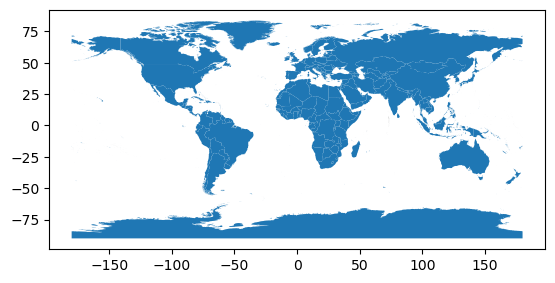

In [7]:
admin.plot()

In [15]:
print(merged.columns.tolist())

['ADMIN', 'geometry', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']


### Create a custom colormap

In [18]:
death_colors = [
    "#ffffff",
    "#ffe5e5",
    "#ffcccc",
    "#ffb3b3",
    "#ff9999",
    "#ff6666",
    "#ff3333",
    "#e60000",
    "#990000",
    "#4d0000"
]

death_cmap = LinearSegmentedColormap.from_list(
    "Deaths",
    death_colors,
    N=10
)

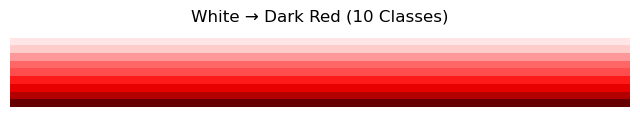

In [17]:
data = np.linspace(0, 1, 100).reshape(10, 10)

plt.figure(figsize=(8, 1))
plt.imshow(data, cmap=covid_cmap, aspect="auto")
plt.axis("off")
plt.title("White → Dark Red (10 Classes)")
plt.show()

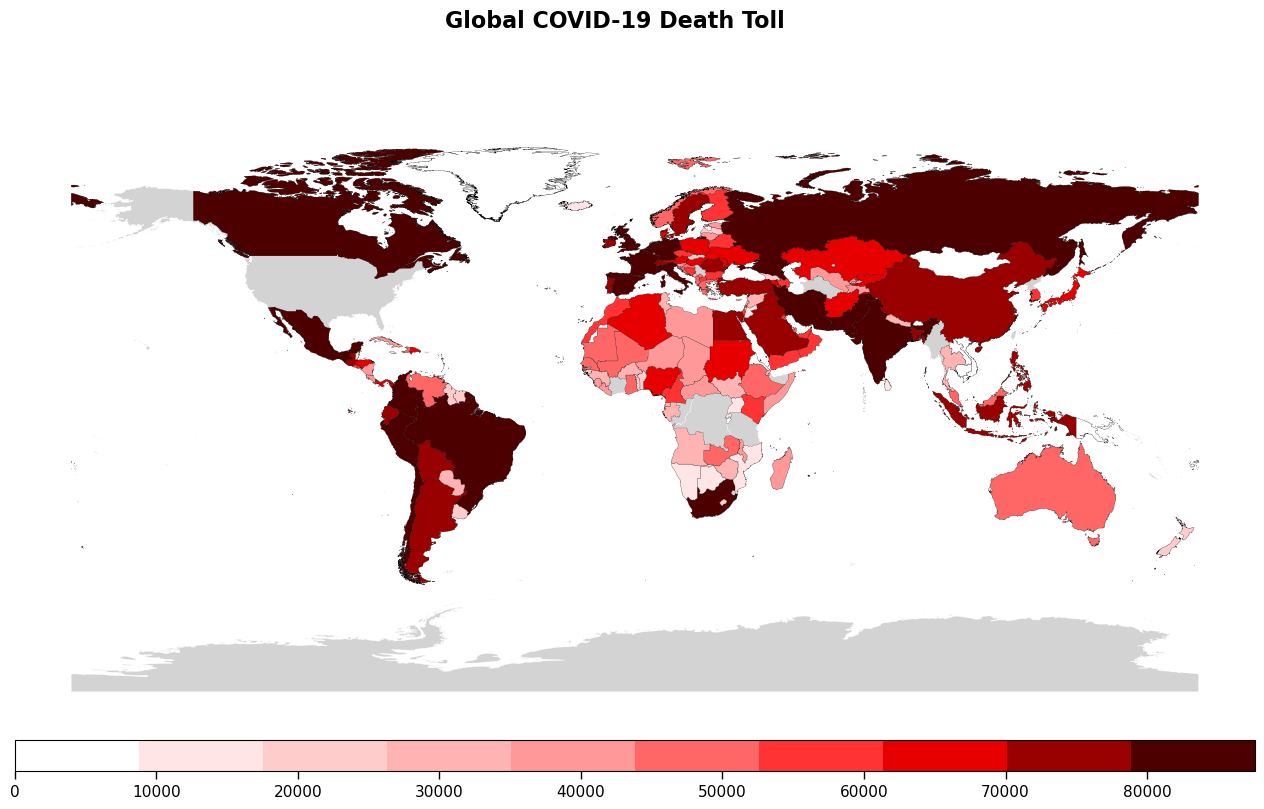

In [34]:
fig, ax = plt.subplots(figsize=(16, 9))

# Figure title (TOP OF THE MAP)
fig.suptitle(
    "Global COVID-19 Death Toll",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

admin.plot(
    ax=ax,
    color="lightgray",
    edgecolor="white",
    linewidth=0.2
)

merged.plot(
    ax=ax,
    column="Deaths",
    cmap=death_cmap,
    scheme="Quantiles",
    k=10,
    legend=False,
    edgecolor="black",
    linewidth=0.15
)

ax.set_axis_off()

norm = Normalize(
    vmin=merged["Deaths"].min(),
    vmax=merged["Deaths"].max()
)

sm = ScalarMappable(
    norm=norm,
    cmap=death_cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",   
    pad=0.03,                   
    fraction=0.05,             
    aspect=40                   
)

# Tick labels
cbar.ax.tick_params(
    labelsize=11,
    length=6,
    width=1
)

# Save
fig.savefig(
    "Covid 19 Death Toll.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches= .40,          
    facecolor="white"
)
plt.show()